In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv(
    "../data/processed/elliptic_clean.csv"
)

data.head()

,time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class
0,-1.556878,0.307025,1.168821,-0.748109,7.643807,-0.053406,6.039024,21.528480,-0.146334,-0.084347,...,-0.619017,0.155526,0.155844,2.115930,0.016322,-0.117599,0.593442,-0.08332,-0.082052,2
1,-1.556878,0.067780,0.271911,-0.226081,2.628539,-0.053406,2.820415,1.501088,-0.146334,-0.127352,...,-0.619017,0.155526,0.155844,1.200416,-0.028141,-0.117599,0.270020,-0.08332,-0.082052,2
2,-1.556878,-0.135517,-0.222646,-1.270138,-0.183761,-0.041930,-0.187137,-0.080022,-0.102664,-0.126685,...,-0.619017,0.155526,0.155844,0.056025,-0.083719,-0.117599,-0.134257,-0.08332,-0.082052,2
3,-1.556878,-0.140505,-0.222646,-1.270138,-0.183761,-0.041930,-0.187137,-0.080022,-0.108753,-0.131978,...,-0.586053,-1.091739,-1.090228,0.056025,-0.083719,-0.117599,-0.134257,-0.08332,-0.082052,2
4,-1.556878,-0.170324,-0.222646,-1.270138,-0.090018,-0.041930,-0.134373,0.447015,-0.146324,-0.164128,...,-0.605832,0.155526,0.155844,0.056025,-0.072604,-0.091257,-0.093830,-1.72568,-1.726407,2


In [2]:
data.shape

(46564, 167)

In [3]:
data['class'].value_counts()

class
2    42019
1     4545
Name: count, dtype: int64

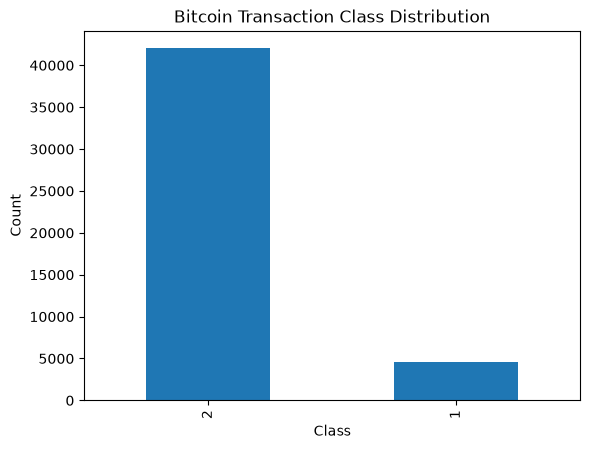

In [4]:
data['class'].value_counts().plot(
    kind='bar'
)

plt.title(
    "Bitcoin Transaction Class Distribution"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Count"
)

plt.show()

In [6]:
data.groupby(
    'class'
)['feature_10'].mean()

class
1   -0.079287
2    0.008576
Name: feature_10, dtype: float64

In [7]:
corr = data.corr()


corr['class'].sort_values(
    ascending=False
).head(10)

class          1.000000
feature_53     0.261472
feature_89     0.227629
feature_55     0.227146
feature_90     0.221294
feature_150    0.187232
feature_91     0.185804
feature_52     0.171799
feature_54     0.142125
feature_114    0.137636
Name: class, dtype: float64

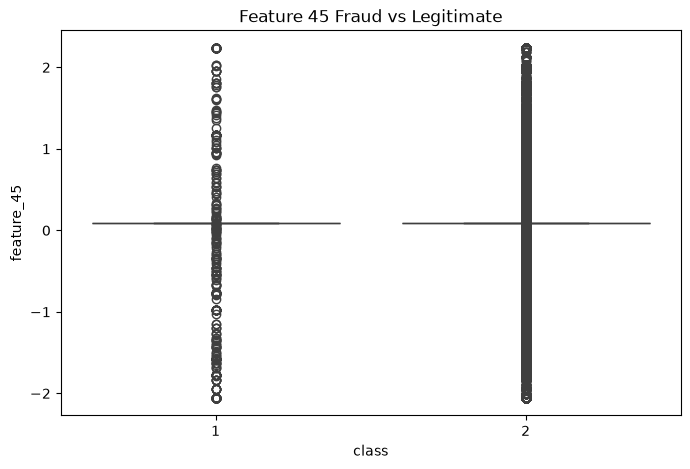

In [8]:
plt.figure(figsize=(8,5))


sns.boxplot(
    x='class',
    y='feature_45',
    data=data
)


plt.title(
"Feature 45 Fraud vs Legitimate"
)

plt.show()

In [9]:
data.groupby(
'class'
)['time'].mean()

class
1    0.031648
2   -0.003423
Name: time, dtype: float64

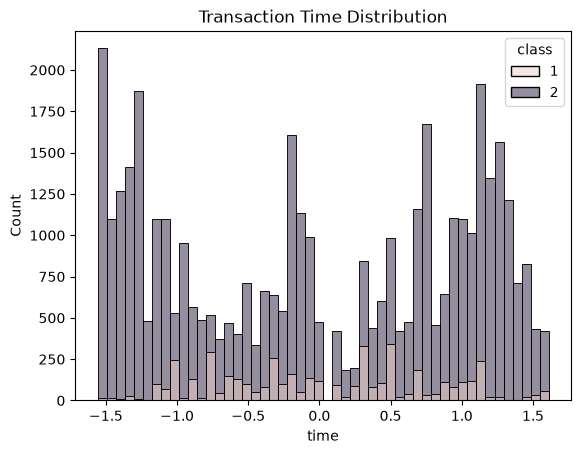

In [10]:
sns.histplot(
data=data,
x='time',
hue='class',
bins=50
)

plt.title(
"Transaction Time Distribution"
)

plt.show()

In [11]:
variance = data.var()


variance.sort_values().head()

class          0.088082
feature_20     1.000021
feature_23     1.000021
feature_5      1.000021
feature_125    1.000021
dtype: float64

In [12]:
X = data.drop(
'class',
axis=1
)

In [13]:
y = data['class']

In [14]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(

X,
y,

test_size=0.2,

random_state=42,

stratify=y

)

In [19]:
data.columns = (
    ['txId','time'] +
    [f'feature_{i}' for i in range(1,166)]
)

data.head()

,txId,time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165
0,-1.556878,0.307025,1.168821,-0.748109,7.643807,-0.053406,6.039024,21.528480,-0.146334,-0.084347,...,-0.619017,0.155526,0.155844,2.115930,0.016322,-0.117599,0.593442,-0.08332,-0.082052,2
1,-1.556878,0.067780,0.271911,-0.226081,2.628539,-0.053406,2.820415,1.501088,-0.146334,-0.127352,...,-0.619017,0.155526,0.155844,1.200416,-0.028141,-0.117599,0.270020,-0.08332,-0.082052,2
2,-1.556878,-0.135517,-0.222646,-1.270138,-0.183761,-0.041930,-0.187137,-0.080022,-0.102664,-0.126685,...,-0.619017,0.155526,0.155844,0.056025,-0.083719,-0.117599,-0.134257,-0.08332,-0.082052,2
3,-1.556878,-0.140505,-0.222646,-1.270138,-0.183761,-0.041930,-0.187137,-0.080022,-0.108753,-0.131978,...,-0.586053,-1.091739,-1.090228,0.056025,-0.083719,-0.117599,-0.134257,-0.08332,-0.082052,2
4,-1.556878,-0.170324,-0.222646,-1.270138,-0.090018,-0.041930,-0.134373,0.447015,-0.146324,-0.164128,...,-0.605832,0.155526,0.155844,0.056025,-0.072604,-0.091257,-0.093830,-1.72568,-1.726407,2


In [20]:
data['transaction_velocity'] = (
    data['time']
    .groupby(data['txId'])
    .transform('count')
)

C:\Users\Hp\AppData\Local\Temp\ipykernel_10324\1027729383.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['transaction_velocity'] = (
